 CLASIFICACIÓN DE DÍGITOS MANUSCRITOS CON MLP (MNIST)
 VERSIÓN DOCUMENTADA COMPLETA
 Incluye:
 - Visualización de datos
 - Entrenamiento
 - Medición de memoria con psutil
 - Métricas (Accuracy, F1-Score)
 - Matriz de confusión


In [1]:
# ==============================
# 1️⃣ IMPORTACIÓN DE LIBRERÍAS
# ==============================

# TensorFlow: Framework principal para redes neuronales
import tensorflow as tf

# Keras: API de alto nivel para construir modelos
from tensorflow import keras

# NumPy: Manejo de arreglos y operaciones matemáticas
import numpy as np

# Matplotlib: Visualización de gráficos
import matplotlib.pyplot as plt

# Métricas de evaluación
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn: Visualización avanzada (para matriz de confusión)
import seaborn as sns

# Librería para medir tiempo de ejecución
import time

# psutil: Permite medir uso de memoria del sistema
import psutil

# os: Permite obtener información del proceso actual
import os

# Permite rastrear y medir el uso y pico de memoria asignada por el programa.
import tracemalloc

In [2]:
# ==============================
# 2️⃣ CARGA DEL DATASET
# ==============================

# Carga automática del dataset MNIST
# Contiene 60.000 imágenes para entrenamiento
# y 10.000 imágenes para prueba
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# x_train: imágenes de entrenamiento (60,000)
# y_train: etiquetas correspondientes
# x_test: imágenes de prueba (10,000)
# y_test: etiquetas de prueba

# Mostrar dimensiones del dataset
print("Numero de Imagenes de Entrenamiento: ", x_train.shape)
print("Numero de Imagenes de Prueba: ", x_test.shape)

Numero de Imagenes de Entrenamiento:  (60000, 28, 28)
Numero de Imagenes de Prueba:  (10000, 28, 28)


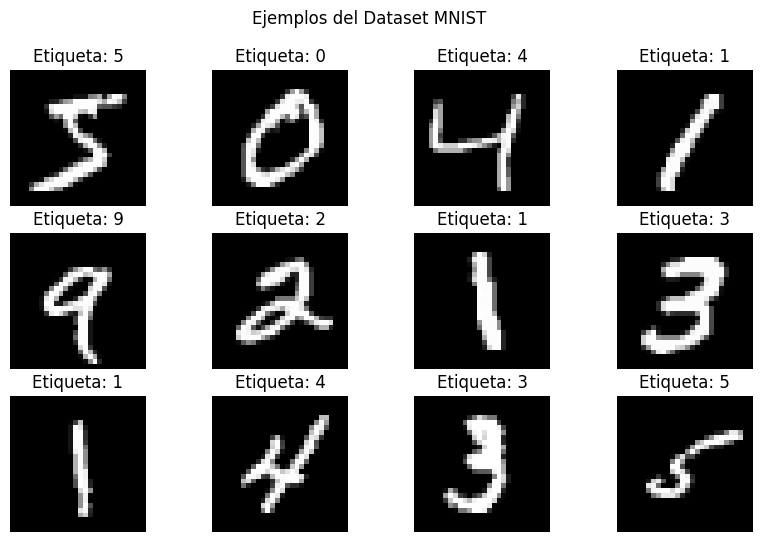

In [3]:
# ==============================
# 3️⃣ VISUALIZACIÓN DE EJEMPLOS
# ==============================

# Crear figura con tamaño personalizado
plt.figure(figsize=(10,6))

# Mostrar 12 imágenes del dataset
for i in range(12):
    plt.subplot(3,4,i+1)  # Organiza en 3 filas y 4 columnas
    plt.imshow(x_train[i], cmap='gray')  # Imagen en escala de grises
    plt.title(f"Etiqueta: {y_train[i]}")  # Mostrar etiqueta real
    plt.axis('off')  # Quitar ejes

plt.suptitle("Ejemplos del Dataset MNIST")
plt.show()

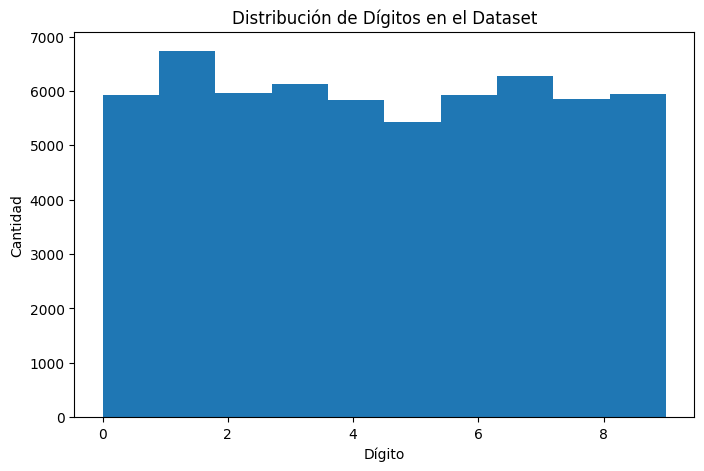

In [4]:
# ==============================
# 4️⃣ DISTRIBUCIÓN DE CLASES
# ==============================

# Mostrar cuántos ejemplos hay por cada dígito (0-9)
plt.figure(figsize=(8,5))
plt.hist(y_train, bins=10)
plt.title("Distribución de Dígitos en el Dataset")
plt.xlabel("Dígito")
plt.ylabel("Cantidad")
plt.show()

In [5]:
# ==============================
# 5️⃣ PREPROCESAMIENTO
# ==============================

# Normalizar valores de píxeles (0-255 → 0-1)
# Esto mejora la estabilidad del entrenamiento
x_train = x_train / 255.0
x_test = x_test / 255.0

# Aplanar imágenes 28x28 → 784 neuronas de entrada
# Necesario para una red MLP (Dense)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [6]:
# ==============================
# 6️⃣ CONSTRUCCIÓN DEL MODELO
# ==============================

# ============================================================
# 🔹 CAPAS OCULTAS
# ============================================================
# ReLU: f(x) = max(0, x)
# activation='relu'
# - La más utilizada actualmente.
# - Evita en gran parte el gradiente desvanecido.
# - Rápida y eficiente computacionalmente.

# LeakyReLU: f(x) = x si x>0, alpha*x si x<0
# layers.Dense(64)
# layers.LeakyReLU(alpha=0.01)
# - Variante de ReLU.
# - Evita el problema de "neuronas muertas".
# - Se define como capa separada.

# ELU (Exponential Linear Unit)
# activation='elu'
# - Similar a ReLU pero suaviza valores negativos.
# - Puede mejorar estabilidad del entrenamiento.

# SELU (Scaled ELU)
# activation='selu'
# - Diseñada para redes auto-normalizadas.
# - Mantiene media y varianza estables.

# GELU (Gaussian Error Linear Unit)
# activation='gelu'
# - Más suave que ReLU.
# - Muy usada en NLP (Transformers).

# Tanh: f(x) entre (-1, 1)
# activation='tanh'
# - Centrada en cero.
# - Puede sufrir gradiente desvanecido.

# Sigmoid: f(x) entre (0, 1)
# activation='sigmoid'
# - Convierte salida en probabilidad.
# - Problema de gradiente desvanecido en redes profundas.

# Softplus: f(x) = ln(1 + e^x)
# activation='softplus')
# - Versión suave de ReLU.

# Softsign: f(x) = x / (1 + |x|)
# activation='softsign'
# - Similar a tanh pero más suave.

# Exponential: f(x) = e^x
# activation='exponential'
# - Se usa en casos específicos.

# ============================================================
# 🔹 CAPAS DE SALIDA (DEPENDE DEL PROBLEMA)
# ============================================================
# 🔸 Clasificación Binaria
# layers.Dense(1, activation='sigmoid')
# - Devuelve probabilidad entre 0 y 1.
# - Se usa con binary_crossentropy.

# 🔸 Clasificación Multiclase
# layers.Dense(10*, activation='softmax') *El 10 depende del numero de clases
# - Devuelve probabilidades que suman 1.
# - Se usa con categorical_crossentropy.

# 🔸 Regresión
# layers.Dense(1, activation='linear') *o simplemente sin activation
# - No aplica restricción de valores.
# - Permite salida continua.

# Modelo secuencial (capas una después de otra)
model = keras.Sequential([

    # Primera capa densa:
    # 128 neuronas
    # Función ReLU (evita gradiente desvanecido)
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
 # keras.layers.Dropout(0.2),
    # Segunda capa oculta
    keras.layers.Dense(64, activation='relu'),
# keras.layers.Dropout(0.2),
    # Capa de salida:
    # 10 neuronas (una por cada dígito)
    # Softmax convierte salidas en probabilidades
    keras.layers.Dense(10, activation='softmax')
])

# Mostrar arquitectura del modelo
model.summary()

c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================
# 7️⃣ COMPILACIÓN
# ==============================

# Configurar entrenamiento
model.compile(

    # Adam: optimizador adaptativo eficiente
    optimizer=keras.optimizers.Adam(learning_rate=0.002), 

    # Función de pérdida para clasificación multiclase
    loss='sparse_categorical_crossentropy',

    # Métrica principal
    metrics=['accuracy']
)

In [9]:
# ==============================
# 8️⃣ ENTRENAMIENTO + MEDICIÓN
# ==============================

# Obtener el proceso actual del sistema
proceso = psutil.Process(os.getpid())

# Memoria antes del entrenamiento (en MB)
memoria_antes = proceso.memory_info().rss / 1024**2

#Iniciar el monitoreo de memoria
tracemalloc.start()

# Registrar tiempo inicial
inicio = time.time()

# Entrenamiento del modelo
history = model.fit(
    x_train,
    y_train,
    epochs=20,           # Número de iteraciones completas
    batch_size=32,       # Tamaño del lote
    validation_split=0.2 # 20% para validación
)

# Registrar tiempo final
fin = time.time()

# Calcular tiempo total
tiempo_total = fin - inicio

#Obtener información de memoria
current, peak = tracemalloc.get_traced_memory()

#Detener el monitoreo
tracemalloc.stop()

# Memoria después del entrenamiento
memoria_despues = proceso.memory_info().rss / 1024**2

# Mostrar métricas de recursos
print(f"\n⏱️ Tiempo total de entrenamiento: {tiempo_total:.2f} segundos")
print(f"💾 Memoria antes: {memoria_antes:.2f} MB")
print(f"💾 Memoria después: {memoria_despues:.2f} MB")
print(f"📈 Memoria adicional utilizada: {memoria_despues - memoria_antes:.2f} MB\n")

mem=psutil.virtual_memory()
print(f"💾 Memoria Usada: {mem.used / (1024**3):.2f} GB / {mem.total / (1024**3):.2f} GB\n")

print(f"💾 Memoria actual usada: {current / 1024**2:.2f} MB")
print(f"🚀 Pico máximo de memoria: {peak / 1024**2:.2f} MB")


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9860 - loss: 0.0441 - val_accuracy: 0.9695 - val_loss: 0.1140
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9884 - loss: 0.0348 - val_accuracy: 0.9742 - val_loss: 0.0912
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9910 - loss: 0.0278 - val_accuracy: 0.9747 - val_loss: 0.1007
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9926 - loss: 0.0230 - val_accuracy: 0.9735 - val_loss: 0.1087
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9767 - val_loss: 0.1024
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9937 - loss: 0.0185 - val_accuracy: 0.9762 - val_loss: 0.1061
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9739 - val_loss: 0.1213
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9946 - loss: 0.0158 - 

In [ ]:
# ==============================
# 9️⃣ EVALUACIÓN EN TEST
# ==============================

# Evaluar desempeño con datos no vistos
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Precisión en Test: {test_acc:.3f}")
print(f"Pérdidas en Test: {test_loss:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0819
Precisión en Test: 0.979
Pérdidas en Test: 0.082


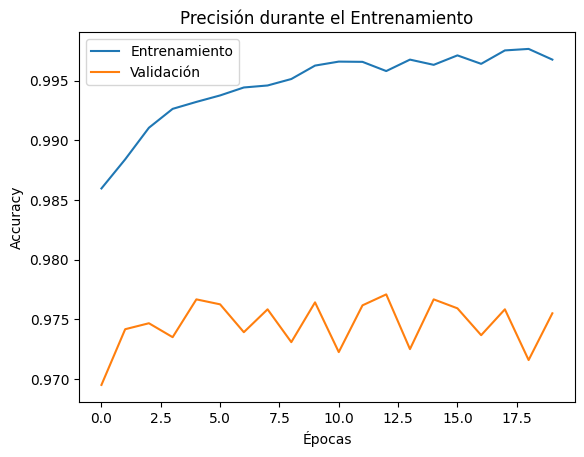

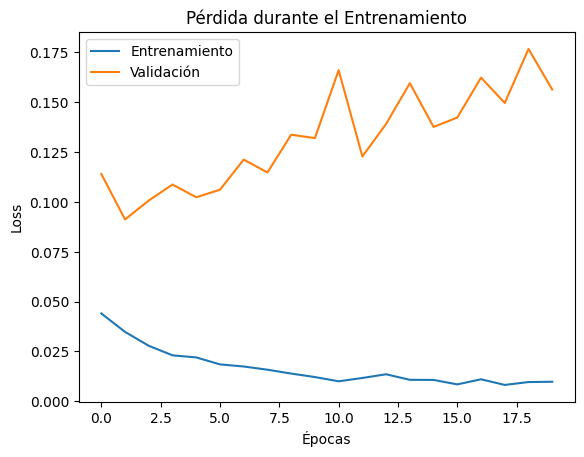

In [ ]:
# ==============================
# 🔟 GRÁFICAS DE ENTRENAMIENTO
# ==============================
# adam 0.001 batch 32
# Precisión
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Precisión durante el Entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend(["Entrenamiento", "Validación"])
plt.show()

# Pérdida
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Pérdida durante el Entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend(["Entrenamiento", "Validación"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

📊 REPORTE DE CLASIFICACIÓN:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



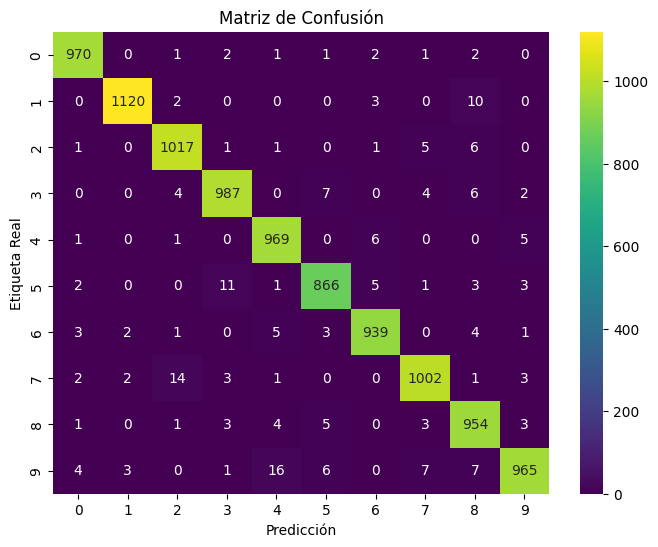

In [ ]:
# ==============================
# 1️⃣1️⃣ REPORTE Y MATRIZ
# ==============================

# Obtener probabilidades
y_pred_prob = model.predict(x_test)

# Convertir probabilidades en clase final
y_pred = np.argmax(y_pred_prob, axis=1)

# Mostrar reporte completo
print("\n📊 REPORTE DE CLASIFICACIÓN:\n")
print(classification_report(y_test, y_pred))

# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar matriz
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.show()

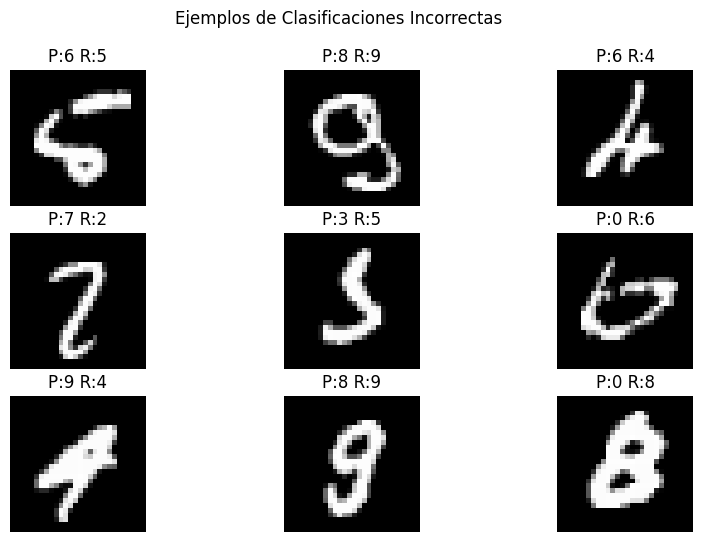

In [ ]:
# ==============================
# 1️⃣2️⃣ VISUALIZAR ERRORES
# ==============================

# Identificar índices donde el modelo se equivocó
errores = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,6))

# Mostrar 9 errores
for i in range(9):
    plt.subplot(3,3,i+1)
    indice = errores[i]

    # Volver a forma 28x28 para visualizar
    plt.imshow(x_test[indice].reshape(28,28), cmap='gray')

    # Mostrar predicción y valor real
    plt.title(f"P:{y_pred[indice]} R:{y_test[indice]}")
    plt.axis('off')

plt.suptitle("Ejemplos de Clasificaciones Incorrectas")
plt.show()